Loaded: (9105, 47)


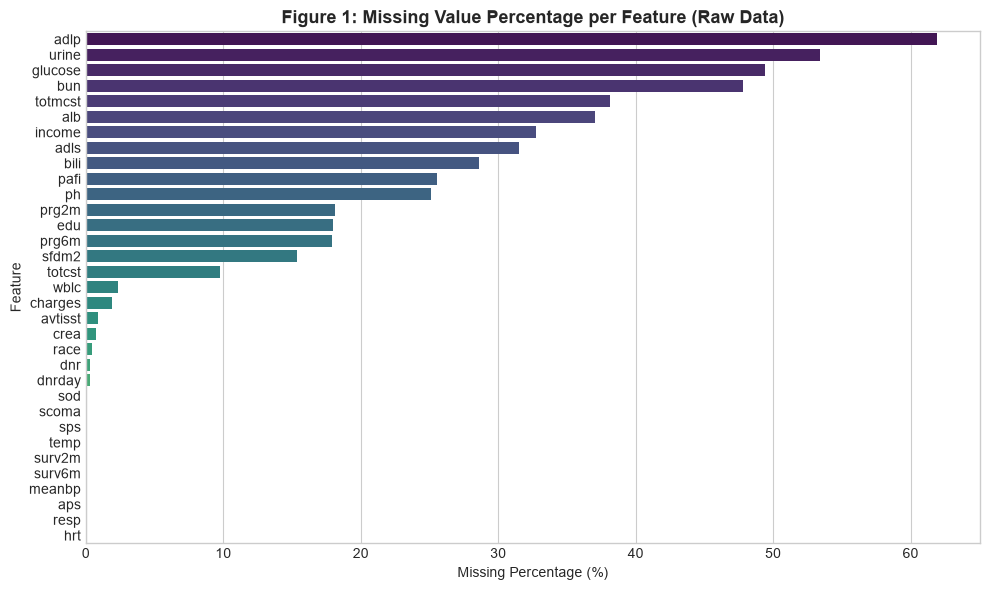

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

raw_df = pd.read_csv("data/raw/support2.csv")
print("Loaded:", raw_df.shape)

# --- Figure 1: Missing values ---
plt.figure(figsize=(10, 6))
missing_pct = (raw_df.isnull().sum() / len(raw_df) * 100).sort_values(ascending=False)
missing_pct = missing_pct[missing_pct > 0]
if not missing_pct.empty:
    sns.barplot(x=missing_pct.values, y=missing_pct.index, hue=missing_pct.index, palette='viridis', legend=False)
    plt.title('Figure 1: Missing Value Percentage per Feature (Raw Data)', fontsize=13, fontweight='bold')
    plt.xlabel('Missing Percentage (%)')
    plt.ylabel('Feature')
    plt.tight_layout()
    plt.show()


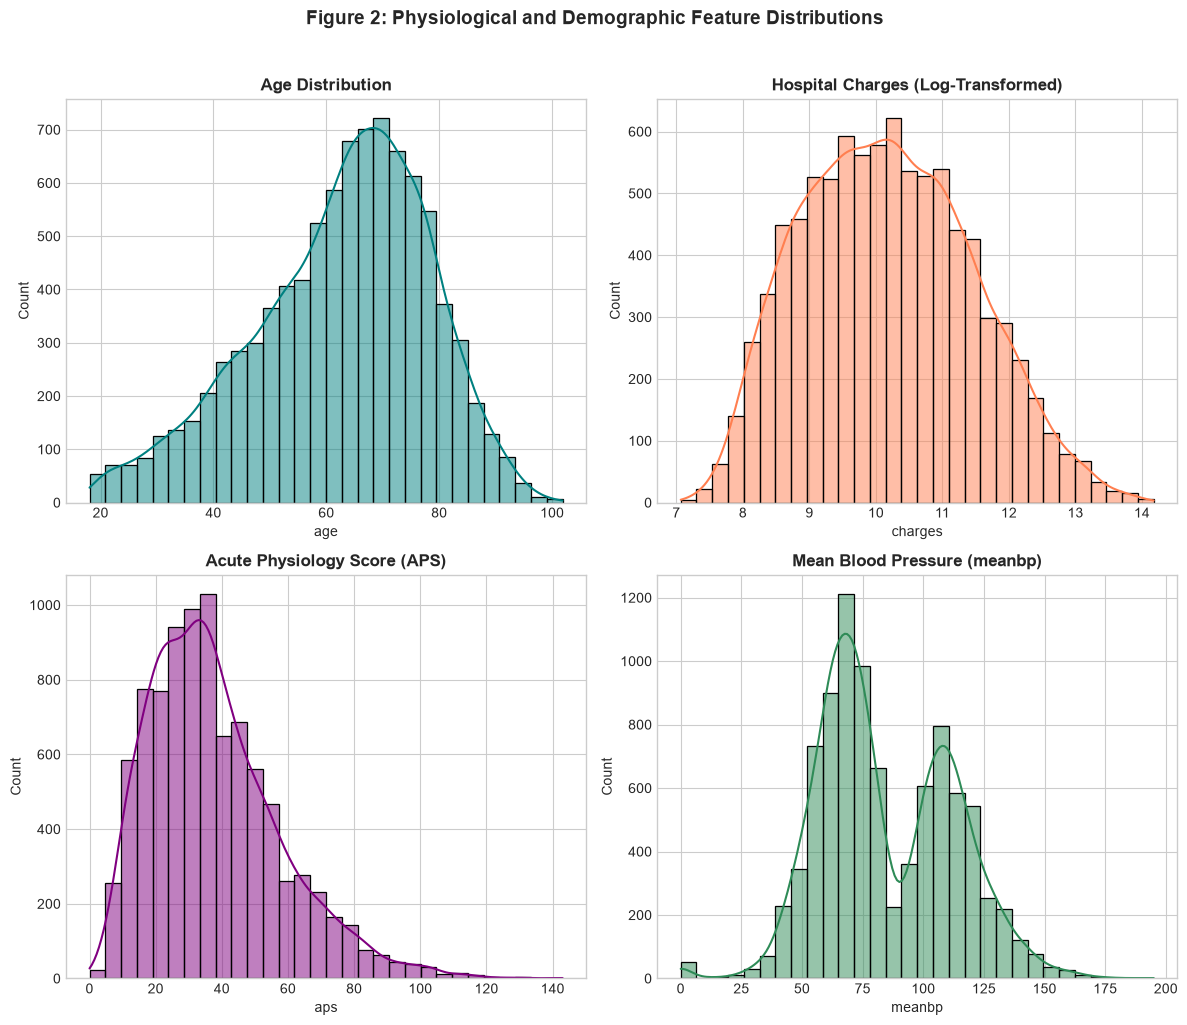

In [2]:
#  Figure 2: Feature distributions 
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
if 'age' in raw_df.columns:
    sns.histplot(raw_df['age'].dropna(), kde=True, ax=axes[0, 0], color='teal', bins=30)
    axes[0, 0].set_title('Age Distribution', fontweight='bold')
if 'charges' in raw_df.columns:
    sns.histplot(np.log1p(raw_df['charges'].dropna()), kde=True, ax=axes[0, 1], color='coral', bins=30)
    axes[0, 1].set_title('Hospital Charges (Log-Transformed)', fontweight='bold')
if 'aps' in raw_df.columns:
    sns.histplot(raw_df['aps'].dropna(), kde=True, ax=axes[1, 0], color='purple', bins=30)
    axes[1, 0].set_title('Acute Physiology Score (APS)', fontweight='bold')
if 'meanbp' in raw_df.columns:
    sns.histplot(raw_df['meanbp'].dropna(), kde=True, ax=axes[1, 1], color='seagreen', bins=30)
    axes[1, 1].set_title('Mean Blood Pressure (meanbp)', fontweight='bold')
plt.suptitle('Figure 2: Physiological and Demographic Feature Distributions', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


In [ ]:
#  Figure 3: Target mortality distributions 
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
if 'hospdead' in raw_df.columns:
    sns.countplot(x='hospdead', data=raw_df, hue='hospdead', palette='Set2', legend=False, ax=axes[0])
    axes[0].set_title('In-Hospital Mortality (hospdead)', fontweight='bold')
    axes[0].set_xticks([0, 1])
    axes[0].set_xticklabels(['Survived', 'Died in Hosp'])
if 'death' in raw_df.columns:
    sns.countplot(x='death', data=raw_df, hue='death', palette='Set1', legend=False, ax=axes[1])
    axes[1].set_title('Overall Follow-up Mortality (death)', fontweight='bold')
    axes[1].set_xticks([0, 1])
    axes[1].set_xticklabels(['Survived', 'Died'])
plt.suptitle('Figure 3: Target Mortality Distribution Analysis', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# --- Figure 4: Mortality by disease group ---
if 'dzgroup' in raw_df.columns and 'hospdead' in raw_df.columns:
    plt.figure(figsize=(11, 6))
    sns.countplot(y='dzgroup', hue='hospdead', data=raw_df, palette='mako')
    plt.title('Figure 4: In-Hospital Mortality Across Disease Groups (dzgroup)', fontsize=13, fontweight='bold')
    plt.xlabel('Patient Count')
    plt.ylabel('Disease Category')
    plt.legend(title='Outcome', labels=['Survived', 'Died'])
    plt.tight_layout()
    plt.show()
